<a href="https://colab.research.google.com/github/codeBMB/google_colabs/blob/BASIL/python_colabs/BASIL/molecule_manipulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="text-align: center;">
        <img src="https://github.com/codeBMB/google_colabs/blob/BASIL/python_colabs/BASIL/images/molssi_logo_header.png?raw=1" alt="MolSSI log" style="height: 250px;">
</div>

# Manipulating Molecules with RDKit

<div class="alert alert-block alert-info">

<h2>Overview</h2>

<strong>Questions</strong>

* How can I load files using RDKit?
* How can I manipulate and create new molecules from an existing molecule?

<strong>Objectives</strong>

* To understand the utility of the different Python libraries utilized in this notebook
* To explain the features of SMILES strings and how they are used to communicate chemical structures to computers
* To modify a ligand file in a meaningful way (*e.g.*, testing stereochemistry or electrochemistry) and to save the modified file for future use

</div>

In this notebook, we load an "ideal" structure for a ligand obtained in the [EC_class_ligands_search](EC_class_ligands_search.ipynb) notebook by pulling coordinates from the PDB and then we manipulate it using RDKit.

The approach taken here is manual and hands on. We will pick atoms of interest visually, then morph atomic numbers in order to change a carbon atom into a nitrogen atom, and then add a methyl group by changing a hydrogen atom into a carbon atom.

By loading our molecule from an ideal structure with 3D coordinates, we can ensure that we're already near a "good structure" for our manipulated molecules and our geometry optimization will be more likely to succeed.

### Libraries for the IQB Workshop

| Library    | Description     |
| :-----------: | :------------ |
| rdkit | Cheminformatics Toolkit |
| Chem | A subset of rdkit for molecule manipulation |
| IPythonConsole | A subset of rdkit to control image quality |
| Draw | A subset of rdkit for structure drawing |
| AllChem | A subset of rdkit for optimizing 3D structures |

After completing this notebook, if you wish to dig deeper on rdkit, consider reading [Getting Started with rdkit in Python](https://www.rdkit.org/docs/GettingStartedInPython.html).

The first thing we need to do is install rdkit because it is not native to the Colab environment. To find out which packages are already present in Colab and do not need to be installed, enter this command in a coding cell:

`!pip list`

In [30]:
!pip install rdkit

## Importing libraries
Now that rdkit is installed, we need to import and configure it. The `import rdkit` command does not automatically load every function in rdkit into the system's memory - it would take up too much space. So we have to load portions of it, like `Chem` and `AllChem`. There is an advantage to using a command like `from rdkit import Chem`. This means that you can call functions from `rdkit.Chem` using just `Chem`. For example, we will use `Chem.MolfromSmiles` later in this notebook.

The `IPythonConsole` functions determine how things will be displayed in the notebook. Feel free to manipulate these to find your preferences for your notebooks and your system.

In [31]:
from rdkit import Chem
from rdkit.Chem.Draw import IPythonConsole
from rdkit.Chem import Draw

# Configuration for displaying in Jupyter notebooks
IPythonConsole.ipython_useSVG = True  # Use SVG for higher quality images
IPythonConsole.drawOptions.addAtomIndices = True  # Show atom indices
IPythonConsole.molSize = 600,600 # Set size of image

## Molecular Representations of Biological Molecules for Computing

In bioinformatics, if you work with genomics you are accustomed to working with DNA sequences. For example, this is a partial DNA sequence for human dihdydrofolate reductase, an important enzyme in nucelotide metabolism.

```
GAATTCATGAAAACGTAGCTCGTCCTCAAAAAAAACAGAAGAGGAGTAATCATTTTAAGGGAGAAATATA
TACGAAAGGAACAAGATTTTGAAGCACCCAAGCTGCCACCTACATTAAAACACGGTAGGTGGCTAAACAC
CAGTCTTCAATGCCCTTCCACAGCCTCAGTCTGAAAAATACTGTGCAGGTGACCCAAGTGAGGGGTCACC
CTTGGGCTTTTCCTGTGGCAGTATCTCTGGTTTAAAAACAAACAAACGTACTTATTGCGTTGAAGGACGG
CAACAGGAAGGACTCCATGATTAGTCACATCTATACCATCCTAAGAAACTTTATCCACCCAAACTGTATT
TCAGACTTTATAATCTAAACTACAAAAAGTGTTCACTGGGGAACTGCACAATATGACTGCTTTTAACCGT
```

The DNA sequence shown here is a simplified representation of a very complex 3D structure that is part of a chromosome, an enormously complex structure. The sequence that represents this gene can be used as a string in coding - computation with strings is orders of magnitude faster than computation with 3D structures. And we can still learn a great deal about this gene simply by exploring the sequence. Likewise we can represent the RNA transcribed from this sequence as a list of characters where T is replaced by U.

If you study proteins or proteomics, you know that protein function depends on protein structure. Protein structures involve 20 (or more) building blocks so the sequences are more complex, but the principle of representing the protein as a simple string for ease with computing still applies. Here is the sequence of the dihydrofolate reductase protein that is coded in this gene sequence above.

```
MVGSLNCIVAVSQNMGIGKNGDLPWPPLRNEFRYFQRMTTTSSVEGKQNLVIMGKKTWFSIPEKNRPLKG
RINLVLSRELKEPPQGAHFLSRSLDDALKLTEQPELANKVDMVWIVGGSSVYKEAMNHPGHLKLFVTRIM
QDFESDTFFPEIDLEKYKLLPEYPGVLSDVQEEKGIKYKFEVYEKND
```

As we move into cheminformatics, we often want to convert small molecule structures, like the aspirin shown here, into strings for computing ease.

![Aspirin.png](https://drive.google.com/uc?export=view&id=1hcWaacd-pIb09Wi9dceVSQIfkXgWC-vD)

There are three well-known string conversions for small molecules, SMILES, InChI, and InChI Key. Here are the SMILES, InChI, and InChI Key strings for aspirin.

SMILES: CC(=O)OC1=CC=CC=C1C(=O)O

InChI: 1S/C9H8O4/c1-6(10)13-8-5-3-2-4-7(8)9(11)12/h2-5H,1H3,(H,11,12)

InChI Key: BSYNRYMUTXBXSQ-UHFFFAOYSA-N

In this workshop we will use SMILES strings. SMILES syntax is explained below.

## Simplified Molecular-Input Line-entry System: SMILES

SMILES stands for "Simplified Molecular-Input Line-Entry System" and is a way to represent molecules as a string of characters.

Consider the molecule ethanol. The image below shows a representation that we are used to seeing in chemistry:

![ethanol](https://drive.google.com/uc?export=view&id=1pBnnNujVdkw43xpDOM27nzICgnn7EqJj)

However, the SMILES representation of this molecule would be "CCO".

You can read more about SMILES at [this tutorial](https://archive.epa.gov/med/med_archive_03/web/html/smiles.html), but rules for atoms and bonds are also repeated below.

### Atoms
SMILES supports all elements in the periodic table. An atom is represented using its respective atomic symbol. Upper case letters refer to non-aromatic atoms; lower case letters refer to aromatic atoms. If the atomic symbol has more than one letter the second letter must be lower case.

### Bonds
```
-	Single bond
=	Double bond
#	Triple bond
*	Aromatic bond
.	Disconnected structures
```
Single bonds are the default and therefore need not be entered. For example, 'CC' would mean that there is a non-aromatic carbon attached to another non-aromatic carbon by a single bond, and the computer would identify the structure as the chemical ethane. It is also assumed that the bond between two lower case atom symbols is aromatic. A blank terminates the SMILES string.

### Branches

A branch from a chain is specified by placing the SMILES symbol(s) for the branch between parenthesis. Some examples:

```

CC(O)C	2-Propanol
CC(=O)C	2-Propanone
```

### Rings

A ring is specified by placing a number directly after the SMILES symbol where the ring closure occurs. This number acts as a marker, indicating that the atoms with the same number are connected, thus forming a ring. For instance:

```
C1CCCC1   cyclopentane
n1ccccc1  Pyridine
```

### SMILES Examples

![SMILES Example 1](https://drive.google.com/uc?export=view&id=1-MFSoAGwqOPiqIUD06reOkBPx4BTMhGC)

![SMILES Example 2](https://drive.google.com/uc?export=view&id=18Ub9L98y8cL_lDLF9wl6pLQxCkt8JFqu)


### Using Online Resources to Create Molecules Including Peptides
Most of the time, you will not need to write a SMILES string by hand. You will be able to look up a molecule's SMILES string from a web database like [PubChem](https://pubchem.ncbi.nlm.nih.gov/).

You can also use tools like this [molecule sketcher from the Protein Data Bank](https://www.rcsb.org/chemical-sketch)
to draw molecules and get their SMILES strings.
* Open [molecule sketcher from the Protein Data Bank](https://www.rcsb.org/chemical-sketch)to launch the ChemAxon MarvinJS application on their site.
* Click the Import Button (top of the MarvinJS window, second button from the left that looks like and open folder).
* Enter Amino Acid Codes:
You can input either 1-letter or 3-letter amino acid codes.
As you type, the application will recognize the codes.
* Click the ADD button in the MarvinJS app window.
* Copy the SMILES string from the box to the left of the MarvinJS app window.

Following these steps, here is the SMILES string for the peptide ACTLLV (Alanine-Cysteine-Threonine-Leucine-Leucine-Valine).

`[H]N[C@@H](C)C(=O)N[C@@H](CS)C(=O)N[C@@H]([C@@H](C)O)C(=O)N[C@@H](CC(C)C)C(=O)N[C@@H](CC(C)C)C(=O)N[C@@H](C(C)C)C(O)=O`

Notice that the SMILES string contains explicit hydrogens and @ or @@ symbols. The @ symbol represents one orientation of a chiral center and @@ symbol represents the opposite orientation of a chiral center.

In the next coding cell, we will use this SMILES string to create a peptide with `rdkit.Chem`.

In [32]:
# Notice the syntax - the SMILES string must be placed inside quotes.

peptide = Chem.MolFromSmiles('[H]N[C@@H](C)C(=O)N[C@@H](CS)C(=O)N[C@@H]([C@@H](C)O)C(=O)N[C@@H](CC(C)C)C(=O)N[C@@H](CC(C)C)C(=O)N[C@@H](C(C)C)C(O)=O')

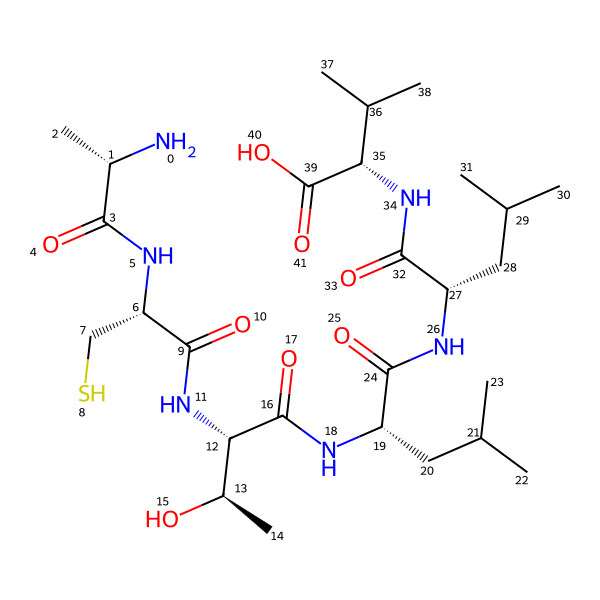

In [33]:
# Once the rdkit Mol object is created, you can simply enter the name
# of the object and it will appear as a 2D structure.

peptide

## 3D Optimization of the Peptide Structure



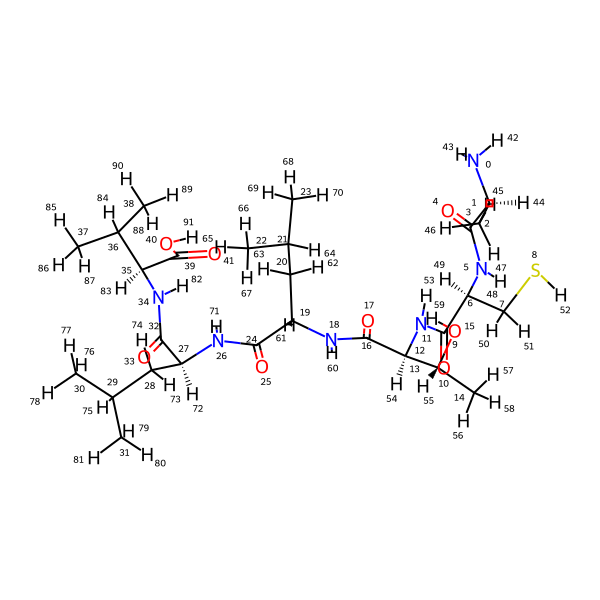

In [34]:
from rdkit import Chem
from rdkit.Chem import AllChem

# Assuming you have a 2D Mol object, for example:
# mol_2d = Chem.MolFromSmiles('CCO') # Replace with your actual 2D Mol object

# Add hydrogens to the molecule
mol_with_h = Chem.AddHs(peptide) # Using the peptide from earlier as an example

# Generate 3D coordinates for the molecule
# -1 refers to a random seed for the conformer generation
# AllChem.EmbedMolecule returns 0 if successful, -1 otherwise
AllChem.EmbedMolecule(mol_with_h, AllChem.ETKDGv3())

# Optimize the 3D structure using the MMFF force field
# AllChem.MMFFOptimizeMolecule returns 0 if successful, 1 if optimization failed
AllChem.MMFFOptimizeMolecule(mol_with_h)

# Display the 3D molecule (optional, depending on your environment setup)
mol_with_h

In [35]:
!pip install py3Dmol

In [36]:
import py3Dmol
from rdkit.Chem import AllChem

# Convert the RDKit Mol object to an SDF string
sdf_string = Chem.MolToMolBlock(mol_with_h)

# Create a py3Dmol view
view = py3Dmol.view(width=400, height=400)

# Add the molecule from the SDF string
view.addModel(sdf_string, 'sdf')

# Style the atoms and bonds
view.setStyle({'stick':{}})
view.zoomTo()

# Display the view
view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [8]:
!pip install pepkit

In [18]:
from pepkit.chem.conversion import fasta_to_smiles, smiles_to_fasta

In [19]:
peptide = "ACTLLV"
peptide_smiles = fasta_to_smiles(peptide)
print(peptide_smiles)

CC(C)C[C@H](NC(=O)[C@H](CC(C)C)NC(=O)[C@@H](NC(=O)[C@H](CS)NC(=O)[C@H](C)N)[C@@H](C)O)C(=O)N[C@H](C(=O)O)C(C)C


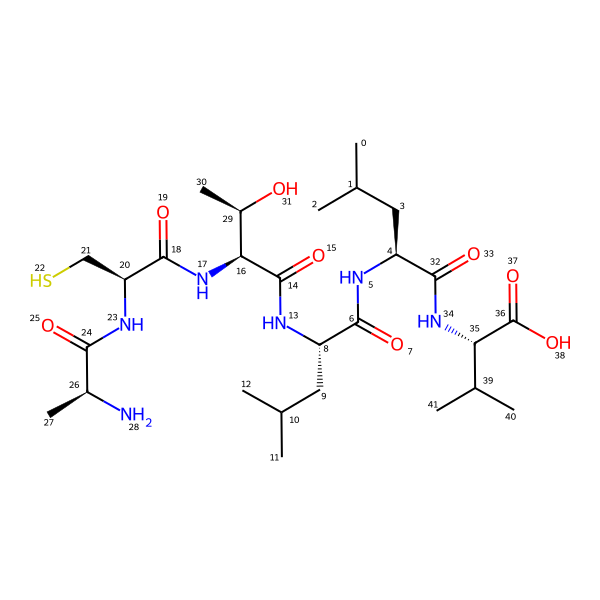

In [20]:
# Notice the syntax - the SMILES string must be placed inside quotes.

peptide2 = Chem.MolFromSmiles(peptide_smiles)
peptide2

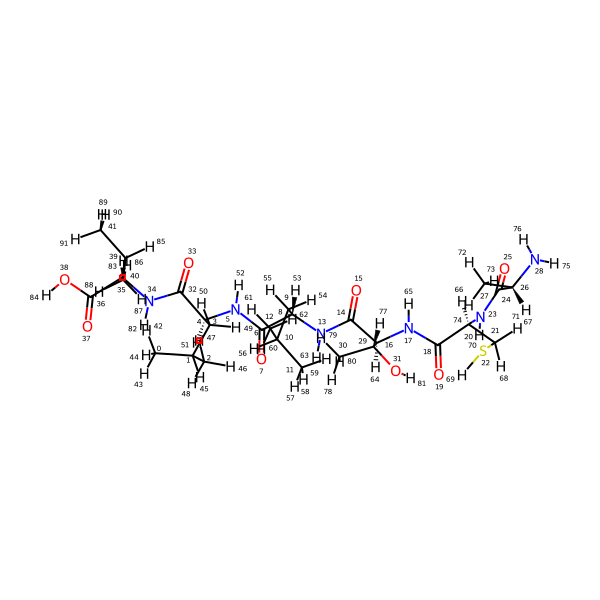

In [21]:
from rdkit import Chem
from rdkit.Chem import AllChem

# Add hydrogens to the molecule
mol2_with_h = Chem.AddHs(peptide2) # Using the peptide from earlier as an example

# Generate 3D coordinates for the molecule
# -1 refers to a random seed for the conformer generation
# AllChem.EmbedMolecule returns 0 if successful, -1 otherwise
AllChem.EmbedMolecule(mol2_with_h, AllChem.ETKDG())

# Optimize the 3D structure using the MMFF force field
# AllChem.MMFFOptimizeMolecule returns 0 if successful, 1 if optimization failed
AllChem.MMFFOptimizeMolecule(mol2_with_h)

# Display the 3D molecule (optional, depending on your environment setup)
mol2_with_h

In [22]:
import py3Dmol
from rdkit.Chem import AllChem

# Convert the RDKit Mol object to an SDF string
sdf_string = Chem.MolToMolBlock(mol_with_h)

# Create a py3Dmol view
view = py3Dmol.view(width=400, height=400)

# Add the molecule from the SDF string
view.addModel(sdf_string, 'sdf')

# Style the atoms and bonds
view.setStyle({'stick':{}})
view.zoomTo()

# Display the view
view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [23]:
import py3Dmol
from rdkit.Chem import AllChem

# Convert the RDKit Mol object to an SDF string
sdf_string = Chem.MolToMolBlock(mol2_with_h)

# Create a py3Dmol view
view = py3Dmol.view(width=400, height=400)

# Add the molecule from the SDF string
view.addModel(sdf_string, 'sdf')

# Style the atoms and bonds
view.setStyle({'stick':{}})
view.zoomTo()

# Display the view
view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [25]:
import py3Dmol
from rdkit import Chem

# Convert mol_with_h to an SDF string
sdf_string_mol1 = Chem.MolToMolBlock(mol_with_h)

# Convert mol2_with_h to an SDF string
sdf_string_mol2 = Chem.MolToMolBlock(mol2_with_h)

# Create the first py3Dmol view for mol_with_h
print("Displaying mol_with_h:")
view1 = py3Dmol.view(query='all', linked=False, width=400, height=400)
view1.addModel(sdf_string_mol1, 'sdf')
view1.setStyle({'stick':{}})
view1.zoomTo()
view1.show()

# Create the second py3Dmol view for mol2_with_h
print("\nDisplaying mol2_with_h:") # Add a newline for better separation
view2 = py3Dmol.view(query='all', linked=False, width=400, height=400)
view2.addModel(sdf_string_mol2, 'sdf')
view2.setStyle({'stick':{}})
view2.zoomTo()
view2.show()

Displaying mol_with_h:


3Dmol.js failed to load for some reason. Please check your browser console for error messages.


Displaying mol2_with_h:


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [28]:
import py3Dmol
from rdkit import Chem

# Convert mol_with_h to an SDF string
sdf_string_mol1 = Chem.MolToMolBlock(mol_with_h)

# Convert mol2_with_h to an SDF string
sdf_string_mol2 = Chem.MolToMolBlock(mol2_with_h)

# Create a single py3Dmol view
view = py3Dmol.view(query='all', linked=False, width=600, height=400)

# Add the first molecule and style it (e.g., red sticks)
view.addModel(sdf_string_mol1, 'sdf')
view.setStyle({'model': 0}, {'stick': {'colorscheme': 'redCarbon'}})

# Add the second molecule and style it (e.g., blue sticks)
view.addModel(sdf_string_mol2, 'sdf')
view.setStyle({'model': 1}, {'stick': {'colorscheme': 'blueCarbon'}})

# Zoom to fit both models
view.zoomTo()

# Display the view
view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

### Modifying a ligand

We will modify [13U: N-cyclooctylglycyl-N-(4-carbamimidoylbenzyl)-L-prolinamide](https://www.rcsb.org/ligand/13U) from the previous notebook as our starting point to create two additional ligands. In one case, we will substitute nitrogen for carbon in an aromatic ring. In the second case, a carbon will be added to the original aromatic ring.

Please notice the index numbers attached to each atom in the ligand image generated by the previous cell. This is possible because of an earlier command that we used to display these index numbers.

`IPythonConsole.drawOptions.addAtomIndices = True  # Show atom indices`

We will use these index numbers to tell the Python code which atoms to modify.

In [ ]:
# load a duplicate copy of 13U to manipulate
mod_ligand_N = Chem.MolFromMolFile("ligands/13U_ideal.sdf")

# change carbon in ring to a nitrogen
mod_ligand_N.GetAtomWithIdx(23).SetAtomicNum()

mod_ligand_N

We can see that the nitrogen we've added has a hydrogen attached to it.
In order to maintain aromaticity, we need to remove this hydrogen.

In [ ]:
atom = mod_ligand_N.GetAtomWithIdx(23) # Select our nitrogen atom
atom.SetNumExplicitHs() # Set the number of explicit hydrogens to 0

In [ ]:
# Look at position 23 now
mod_ligand_N

Now we'll perform the same operations, but this time add a methyl group to the ring.
In this notebook, we're going to be tricky and morph the hydrogen on the carbon atom to a carbon atom.
However, a more "standard" way to do this would be to create two molecule fragments and then merge them together.
To be consistent with our above approach, we'll do it the tricky way.

In [ ]:
# load another duplicate of the original ligand, but keep the hydrogens

mod_ligand_methyl = Chem.MolFromMolFile("ligands/13U_ideal.sdf", )
mod_ligand_methyl        # This is the original structure. In the cells below, we will convert Hydrogen-59 to a Carbon.

In [ ]:
# Use the index number to select the atom we want to change - look at image to see we want to morph atom 59
atom = mod_ligand_methyl.GetAtomWithIdx(62)

atom.SetAtomicNum(6) # Change the atom to carbon
atom.SetNumExplicitHs(3) # Add 3 explicit hydrogens to the carbon

mod_ligand_methyl = Chem.RemoveAllHs(mod_ligand_methyl) # Remove the H's for viewing
mod_ligand_methyl

Now that we have our manipulated molecules, we'll optimize them using RDKit and save them.

In [ ]:
# Optimize new molecules and save
from rdkit.Chem import

Chem.SanitizeMol(mod_ligand_N)
mod_ligand_NH = Chem.AddHs(mod_ligand_N)

# Do a constrained embedding to keep the ligand in the same position
# this allows for the hydrogens to be added in reasonable locations, but keeps
# the heavy atoms in the same position
# See https://rdkit.org/docs/source/rdkit.Chem.AllChem.html#rdkit.Chem.AllChem.ConstrainedEmbed
constrained_mol = AllChem.ConstrainedEmbed(mod_ligand_NH, mod_ligand_N, useTethers=True)
constrained_mol

In [ ]:
# Perform geometry optimization
opt_N = AllChem.MMFFOptimizeMolecule(mod_ligand_NH)
mod_ligand_NH

In [ ]:
# Repeat process on methyl ligand

Chem.SanitizeMol(mod_ligand_methyl)
mod_ligand_methylH = Chem.AddHs(mod_ligand_methyl)

constrained_mol = AllChem.ConstrainedEmbed(mod_ligand_methylH, mod_ligand_methyl, useTethers=True)
constrained_mol

In [ ]:
opt_methyl = AllChem.MMFFOptimizeMoleculeConfs(mod_ligand_methylH)
Chem.(mod_ligand_methylH)

In [ ]:
# save to new files
import os

# make modified ligand directory
os.makedirs("ligands_to_dock", exist_ok=True)

 = Chem.MolFromMolFile("ligands/13U_ideal.sdf", removeHs=False)

# save modified ligands sdf file - make sure all contain hydrogens and place
# in a folder of ligands to dock.
Chem.MolToMolFile(ligand_H, 'ligands_to_dock/13U.sdf')
Chem.MolToMolFile(mod_ligand_NH, 'ligands_to_dock/13U_modified_N.sdf')
Chem.MolToMolFile(mod_ligand_methylH, 'ligands_to_dock/13U_modified_methyl.sdf')

<div class="alert alert-block alert-warning">

<h3>Exercise</h3>

Take a different ligand from the ligands folder and define that as the ligand you wish to work with in the command

`ligand = Chem.MolFromMol2File("ligands/13U_ideal.mol2")`

Use the commands from this notebook to identify one hydrogen that you would like to change to a hydroxyl (-OH) group. Then make the change.
</div>